# Gradient Boosting — From Scratch

Gradient Boosting (Friedman, 2001) is the algorithm behind sklearn's
GradientBoostingClassifier and the conceptual ancestor of XGBoost, LightGBM, CatBoost.

**Core insight**: boosting is gradient descent in function space.
Each tree corrects the errors of all previous trees by fitting the negative gradient.


In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor as SKGBReg
from sklearn.ensemble import GradientBoostingClassifier as SKGBClf
%matplotlib inline

from gradient_boosting import GradientBoostingRegressor, GradientBoostingClassifier
np.random.seed(42)


## 1. The Algorithm Step by Step

```
F_0(x) = mean(y)                          ← best constant prediction

For m = 1 to M:
  r_i = y_i - F_{m-1}(x_i)               ← residuals (negative gradient of MSE)
  h_m = fit tree to (X, r)                ← tree predicts residuals
  F_m(x) = F_{m-1}(x) + lr × h_m(x)     ← update predictions

Return F_M(x)
```

Key insight: for MSE loss, negative gradient = residuals.
For other losses, the "pseudo-residuals" are the negative gradient of that loss.


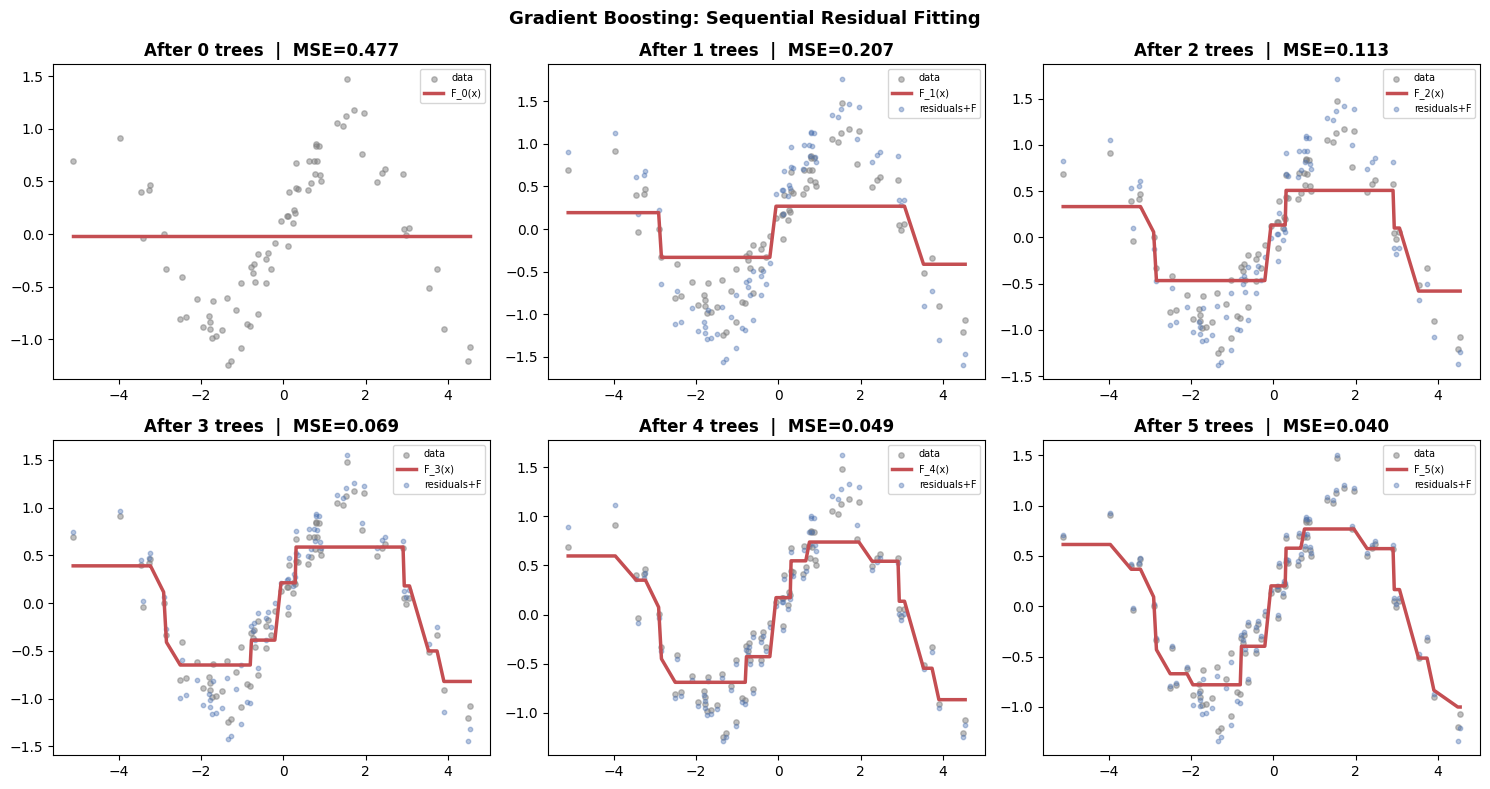

In [2]:
# Step-by-step trace on a tiny 1D regression problem
np.random.seed(0)
X_1d = np.sort(np.random.randn(80, 1) * 2, axis=0)
y_1d = np.sin(X_1d[:, 0]) + np.random.randn(80) * 0.2

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

F = np.full(len(y_1d), y_1d.mean())  # F_0

from decision_tree import DecisionTreeRegressor
lr = 0.5

for i, ax in enumerate(axes):
    residuals = y_1d - F
    if i > 0:
        tree = DecisionTreeRegressor(max_depth=2)
        tree.fit(X_1d, residuals)
        F = F + lr * tree.predict(X_1d)

    ax.scatter(X_1d, y_1d, s=15, alpha=0.5, label='data', color='gray')
    ax.plot(X_1d, F, color='#C44E52', linewidth=2.5, label=f'F_{i}(x)')
    if i > 0:
        ax.scatter(X_1d, residuals + F, s=10, color='#4C72B0', alpha=0.4, label='residuals+F')
    mse = np.mean((y_1d - F)**2)
    ax.set_title(f'After {i} trees  |  MSE={mse:.3f}', fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Gradient Boosting: Sequential Residual Fitting', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## 2. Learning Rate vs Number of Trees

Lower learning rate = more trees needed, but usually better generalization.
This is called the **shrinkage** trade-off.


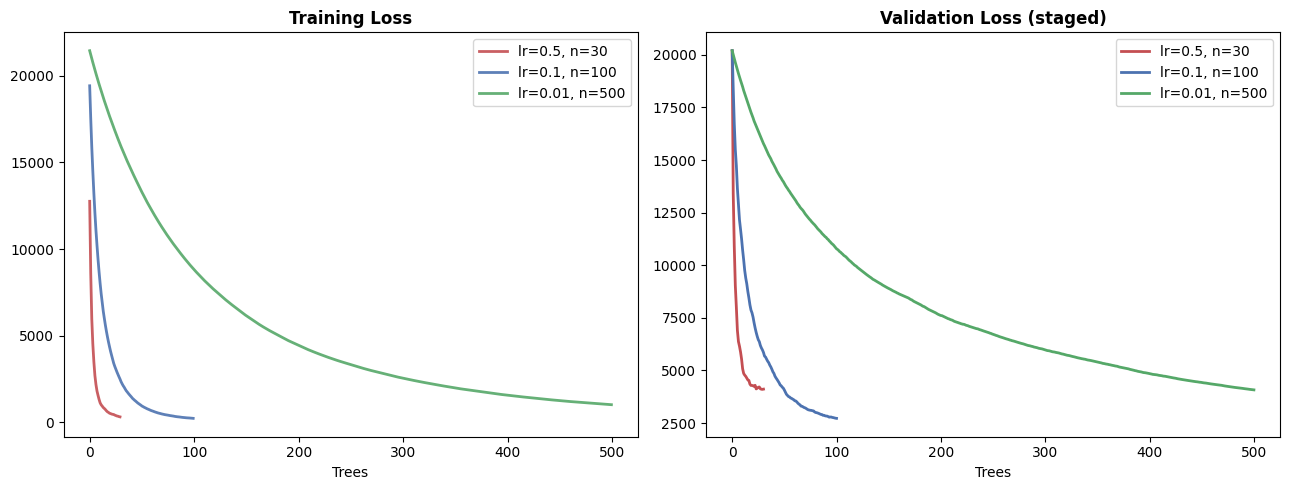

In [3]:
X, y = make_regression(n_samples=500, n_features=10, noise=20, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

configs = [(0.5, 30, '#C44E52'), (0.1, 100, '#4C72B0'), (0.01, 500, '#55A868')]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for lr, n_est, color in configs:
    gb = GradientBoostingRegressor(n_estimators=n_est, learning_rate=lr,
                                    max_depth=3, random_state=42).fit(X_tr, y_tr)
    ax1.plot(gb.train_loss_, color=color, linewidth=2,
             label=f'lr={lr}, n={n_est}', alpha=0.9)

    # staged prediction on test
    test_losses = [np.mean((y_te - p)**2) for p in gb.staged_predict(X_te)]
    ax2.plot(test_losses, color=color, linewidth=2, label=f'lr={lr}, n={n_est}')

ax1.set_title('Training Loss', fontweight='bold'); ax1.set_xlabel('Trees'); ax1.legend()
ax2.set_title('Validation Loss (staged)', fontweight='bold'); ax2.set_xlabel('Trees'); ax2.legend()
plt.tight_layout(); plt.show()


## 3. Stochastic Gradient Boosting

Setting `subsample < 1` means each tree sees only a random subset of the data.
This adds variance-reducing randomization — often improves generalization.


In [4]:
results = {}
for subsample in [1.0, 0.8, 0.5]:
    gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                    max_depth=3, subsample=subsample,
                                    random_state=42).fit(X_tr, y_tr)
    results[subsample] = {'train': gb.score(X_tr, y_tr), 'test': gb.score(X_te, y_te)}
    print(f"subsample={subsample}: train R²={results[subsample]['train']:.4f}  "
          f"test R²={results[subsample]['test']:.4f}")


subsample=1.0: train R²=0.9889  test R²=0.8626
subsample=0.8: train R²=0.9894  test R²=0.8787
subsample=0.5: train R²=0.9866  test R²=0.8983


## 4. Validation Against sklearn

In [5]:
my_gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1,
                                   max_depth=3, random_state=42).fit(X_tr, y_tr)
sk_gb = SKGBReg(n_estimators=50, learning_rate=0.1,
                max_depth=3, random_state=42).fit(X_tr, y_tr)

print(f"My R²:      {my_gb.score(X_te, y_te):.4f}")
print(f"sklearn R²: {sk_gb.score(X_te, y_te):.4f}")
print(f"Difference: {abs(my_gb.score(X_te, y_te) - sk_gb.score(X_te, y_te)):.4f}")

# Prediction correlation
my_preds = my_gb.predict(X_te)
sk_preds = sk_gb.predict(X_te)
print(f"Prediction correlation: {np.corrcoef(my_preds, sk_preds)[0,1]:.4f}")


My R²:      0.7947
sklearn R²: 0.7963
Difference: 0.0016
Prediction correlation: 0.9999
